# Filtrage High / Low

On va appliquer un clustering k=2, puis garder tous les individus qui ont au moins 1 obs dans le groupe high

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../DATA/Data_concat/donnees_compilees.csv')
data.head(10)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,ranking
0,A N Gratchev,2023-01-01,2,0.2,0,0.0,0,0.0,2,0.2,...,0,0.0,0,0,0,0,0,0,0.000000,8735
1,A N Gratchev,2024-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0,0.0,0,0,0,0,3,3,0.076447,8223
2,A N Gratchev,2025-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0,0.0,0,0,0,0,3,6,0.129972,5888
3,Aadel A Chaudhuri,2023-01-01,2,6.9,0,0.0,0,0.0,2,6.9,...,0,0.0,0,0,0,0,0,0,0.000000,1935
4,Aadel A Chaudhuri,2024-01-01,3,0.3,1,0.1,0,0.0,2,0.2,...,0,0.0,1,0,0,1,53,67,4.834006,2155
5,Aadel A Chaudhuri,2025-01-01,2,29.8,1,29.7,0,0.0,1,0.1,...,0,0.0,0,0,0,0,7,14,1.064320,2307
6,Aakash Desai,2023-01-01,5,20.1,1,4.0,4,16.1,0,0.0,...,0,0.0,0,0,0,0,3,3,0.745592,285
7,Aakash Desai,2024-01-01,7,22.2,3,8.0,3,14.1,1,0.1,...,0,0.0,3,0,2,1,110,112,9.115923,300
8,Aakash Desai,2025-01-01,12,83.3,8,54.5,2,13.8,2,15.0,...,0,0.0,3,2,1,1,354,366,29.269657,309
9,Aaron Allen,2023-01-01,2,8.7,2,8.7,0,0.0,0,0.0,...,0,0.0,0,0,0,0,3,3,0.686332,9893


In [3]:
data['annee'] = pd.to_datetime(data['annee'])
data["entity_annee"] = (
    data["entity"].astype(str)
    + "_" 
    + data["annee"].dt.year.astype(str)
)

In [4]:
data_X = data.drop(columns=['ranking','entity','annee'])
data_X.head(10)

,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,guid_count_publications,guid_sum_Impact_factor,...,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,entity_annee
0,2,0.2,0,0.0,0,0.0,2,0.2,0,0.0,...,0,0.0,0,0,0,0,0,0,0.000000,A N Gratchev_2023
1,1,0.1,0,0.0,0,0.0,1,0.1,0,0.0,...,0,0.0,0,0,0,0,3,3,0.076447,A N Gratchev_2024
2,1,0.1,0,0.0,0,0.0,1,0.1,0,0.0,...,0,0.0,0,0,0,0,3,6,0.129972,A N Gratchev_2025
3,2,6.9,0,0.0,0,0.0,2,6.9,0,0.0,...,0,0.0,0,0,0,0,0,0,0.000000,Aadel A Chaudhuri_2023
4,3,0.3,1,0.1,0,0.0,2,0.2,0,0.0,...,0,0.0,1,0,0,1,53,67,4.834006,Aadel A Chaudhuri_2024
5,2,29.8,1,29.7,0,0.0,1,0.1,0,0.0,...,0,0.0,0,0,0,0,7,14,1.064320,Aadel A Chaudhuri_2025
6,5,20.1,1,4.0,4,16.1,0,0.0,0,0.0,...,0,0.0,0,0,0,0,3,3,0.745592,Aakash Desai_2023
7,7,22.2,3,8.0,3,14.1,1,0.1,0,0.0,...,0,0.0,3,0,2,1,110,112,9.115923,Aakash Desai_2024
8,12,83.3,8,54.5,2,13.8,2,15.0,0,0.0,...,0,0.0,3,2,1,1,354,366,29.269657,Aakash Desai_2025
9,2,8.7,2,8.7,0,0.0,0,0.0,0,0.0,...,0,0.0,0,0,0,0,3,3,0.686332,Aaron Allen_2023


In [9]:
# On met 'entity' en index
data_clust = data_X.set_index('entity_annee')

# On ne garde que les colonnes numériques pour le clustering
X = data_clust.select_dtypes(include=['number'])

# Normalisation (fortement recommandé pour k-means et clustering hiérarchique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.cluster import KMeans

# Choisis le nombre de clusters, par ex. k = 4
k = 2

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data_clust['cluster_kmeans'] = kmeans_labels

# Visualiser les premiers résultats
print(data_clust[['cluster_kmeans']].head())

                        cluster_kmeans
entity_annee                          
A N Gratchev_2023                    0
A N Gratchev_2024                    0
A N Gratchev_2025                    0
Aadel A Chaudhuri_2023               0
Aadel A Chaudhuri_2024               0


In [11]:
data_clust = data_clust.merge(
    data[['entity_annee','entity','annee', 'ranking']],   # on ne garde que ce qui est utile
    on='entity_annee',
    how='left'                          # on garde toutes les lignes de data_clust
)
# Moyenne du ranking par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].mean())

# Statistiques détaillées par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].describe())

cluster_kmeans
0    7037.651137
1     286.666402
Name: ranking, dtype: float64
                  count         mean          std    min     25%     50%  \
cluster_kmeans                                                             
0               37863.0  7037.651137  3814.350346  101.0  3629.0  7053.0   
1                1259.0   286.666402   249.745762    1.0   107.0   223.0   

                    75%      max  
cluster_kmeans                    
0               10436.0  13045.0  
1                 393.0   2266.0  


<Figure size 800x500 with 0 Axes>

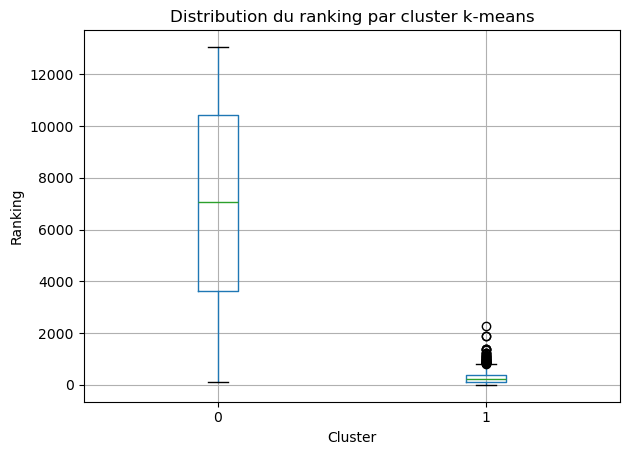

In [12]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_kmeans')
plt.title("Distribution du ranking par cluster k-means")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [13]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
# Variance des centres par variable
importance = centers.var(axis=0)  # variance sur les lignes (clusters)

importance_sorted = importance.sort_values(ascending=False)
importance_sorted.to_csv("../OUTPUTS/Var_kmeans_importance_all_k2.csv")
print(importance_sorted)

count_collab_a-1             5.987969
sum_score_collab_a-1         5.862823
count_collab_a-2             5.647178
sum_score_collab_a-2         5.632419
count_collab                 5.609383
                               ...   
guid_sum_first_author_a-1    0.031188
guid_count_Last_Author       0.022250
guid_count_First_Author      0.022250
guid_sum_first_author        0.020427
guid_sum_last_author         0.020427
Length: 69, dtype: float64


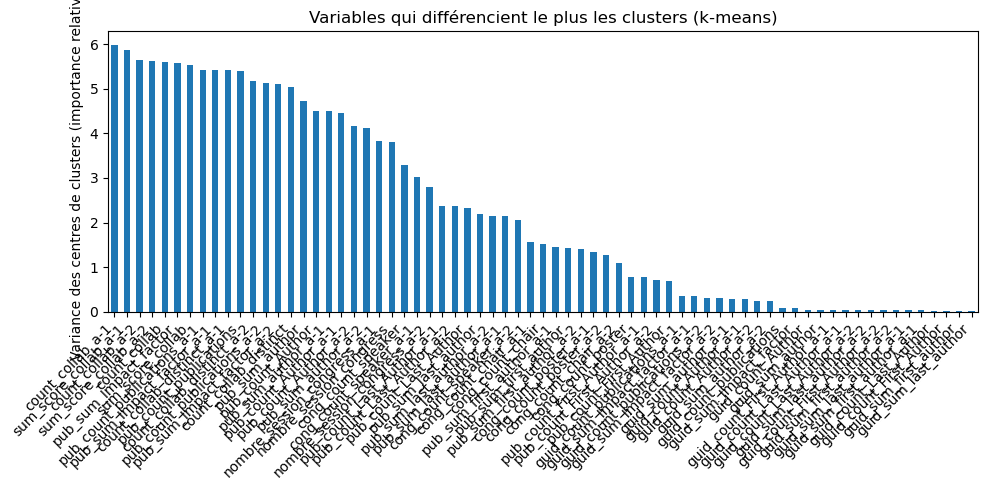

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
importance_sorted.plot(kind='bar')
plt.ylabel("Variance des centres de clusters (importance relative)")
plt.title("Variables qui différencient le plus les clusters (k-means)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Clust hier

In [15]:
from sklearn.cluster import AgglomerativeClustering

# Choisis le nombre de clusters, par ex. 4
hclust = AgglomerativeClustering(n_clusters=2, linkage='ward')
hclust_labels = hclust.fit_predict(X_scaled)

data_clust['cluster_hier'] = hclust_labels

print(data_clust[['cluster_hier']].head())
print(data_clust['cluster_hier'].value_counts())

   cluster_hier
0             1
1             1
2             1
3             1
4             1
cluster_hier
1    38460
0      662
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

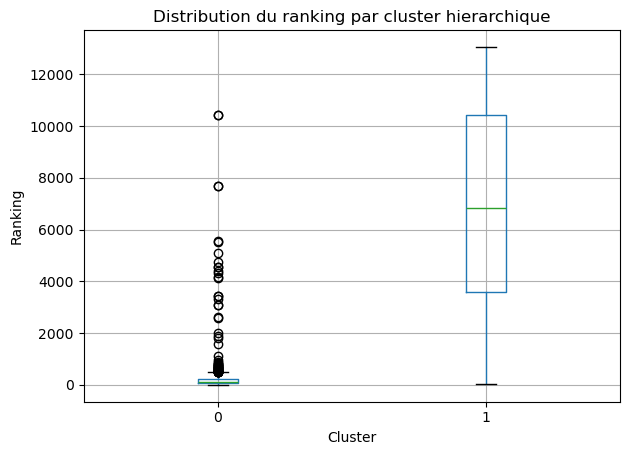

In [16]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_hier')
plt.title("Distribution du ranking par cluster hierarchique")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [17]:
# Mapping pour cluster_kmeans
mapping_kmeans = {
    0: "Other",
    1: "High"
}

# Mapping pour cluster_hier
mapping_hier = {
    0: "High",
    1: "Other"
}

data_clust["cluster_kmeans"] = data_clust["cluster_kmeans"].replace(mapping_kmeans)
data_clust["cluster_hier"]   = data_clust["cluster_hier"].replace(mapping_hier)

In [18]:
# 1) Récupérer les entity pour lesquelles cluster_hier == "high"
entities_high = data_clust.loc[data_clust["cluster_hier"] == "High", "entity"]

# 2) Garder uniquement les lignes dont entity est dans ce sous-ensemble
data_clust_high_subset = data_clust[data_clust["entity"].isin(entities_high)]

data_clust_high_subset.describe()

,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,guid_count_publications,guid_sum_Impact_factor,...,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,annee,ranking
count,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,...,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942,942.000000
mean,11.856688,151.917410,8.489384,116.229406,0.978769,14.770594,2.392781,20.917410,0.032909,1.757431,...,0.240764,1.338641,0.316348,0.397028,1.200637,159.607219,205.454352,21.842575,2024-01-01 08:00:00,407.479830
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-01-01 00:00:00,1.000000
25%,6.000000,58.000000,4.000000,38.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,53.000000,66.250000,8.232532,2023-01-01 00:00:00,79.250000
50%,11.000000,114.800000,8.000000,86.600000,1.000000,0.100000,2.000000,5.600000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,106.000000,142.000000,16.702975,2024-01-01 00:00:00,167.000000
75%,16.000000,207.600000,12.000000,162.200000,1.750000,10.900000,3.000000,22.950000,0.000000,0.000000,...,0.000000,2.000000,0.000000,0.000000,1.000000,200.000000,270.000000,32.140671,2025-01-01 00:00:00,309.750000
max,52.000000,923.200000,36.000000,786.600000,8.000000,260.600000,20.000000,472.200000,2.000000,113.400000,...,113.400000,17.000000,8.000000,7.000000,19.000000,931.000000,1288.000000,100.000000,2025-01-01 00:00:00,10904.000000
std,7.639156,136.533885,5.822872,109.949611,1.315959,32.248377,2.790730,38.876018,0.239509,13.194054,...,4.521143,2.263928,0.923036,0.848523,2.533323,156.453090,199.389860,18.455271,NaN,1070.507165


In [24]:
data_clust_high_subset.shape

(942, 75)

In [25]:
data_clust_high_subset.groupby("entity").size().reset_index(name="n").describe()

,n
count,314.0
mean,3.0
std,0.0
min,3.0
25%,3.0
50%,3.0
75%,3.0
max,3.0


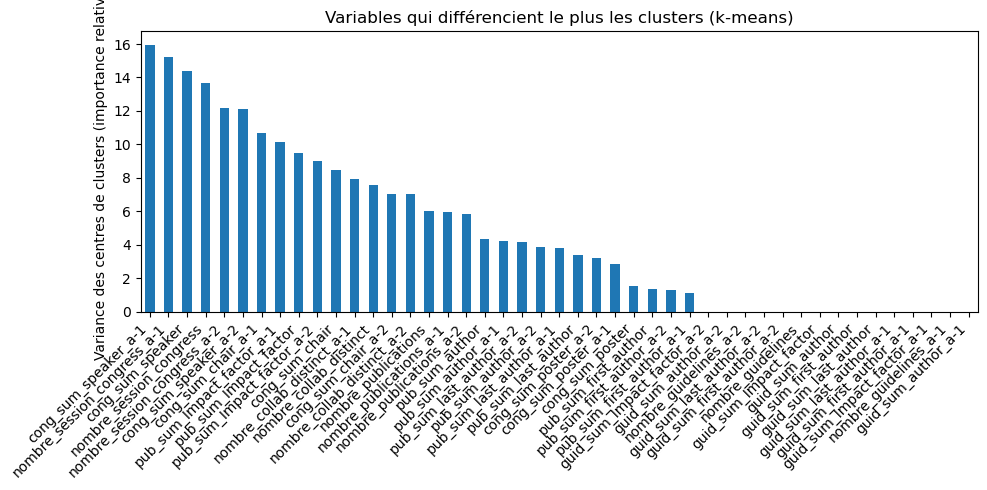

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
importance_sorted.plot(kind='bar')
plt.ylabel("Variance des centres de clusters (importance relative)")
plt.title("Variables qui différencient le plus les clusters (k-means)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# data_clust_high_subset.head(10)
data_clust_high_subset_X = data_clust_high_subset.drop(columns=['entity_annee','entity','annee','ranking','cluster_kmeans','cluster_hier'])
data_clust_high_subset_X

,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,guid_count_publications,guid_sum_Impact_factor,...,guid_sum_first_author_a-2,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2
6,5,20.1,1,4.0,4,16.1,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,3,3,0.745592
7,7,22.2,3,8.0,3,14.1,1,0.1,0,0.0,...,0.0,0,0.0,3,0,2,1,110,112,9.115923
8,12,83.3,8,54.5,2,13.8,2,15.0,0,0.0,...,0.0,0,0.0,3,2,1,1,354,366,29.269657
21,4,104.5,4,104.5,0,0.0,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,40,41,11.102760
22,5,68.8,4,65.8,0,0.0,1,3.0,0,0.0,...,0.0,0,0.0,5,0,3,2,323,336,30.156900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39000,15,155.6,12,78.0,2,73.6,1,4.0,0,0.0,...,0.0,0,0.0,0,0,0,0,120,141,12.114756
39001,11,124.4,9,82.7,1,41.6,1,0.1,0,0.0,...,0.0,0,0.0,1,0,1,0,364,415,31.151562
39077,4,59.1,2,13.0,1,42.1,1,4.0,0,0.0,...,0.0,0,0.0,0,0,0,0,23,25,6.508233
39078,4,39.3,3,32.2,1,7.1,0,0.0,0,0.0,...,0.0,0,0.0,3,1,0,4,52,55,5.168288


In [29]:
# data_clust_high_subset_X

# On ne garde que les colonnes numériques pour le clustering
X = data_clust_high_subset_X.select_dtypes(include=['number'])

# Normalisation (fortement recommandé pour k-means et clustering hiérarchique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# Choisis le nombre de clusters, par ex. 4
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
hclust_labels = hclust.fit_predict(X_scaled)

data_clust_high_subset['cluster_hier_high'] = hclust_labels

print(data_clust_high_subset[['cluster_hier_high']].head())
print(data_clust_high_subset['cluster_hier_high'].value_counts())

    cluster_hier_high
6                   2
7                   2
8                   2
21                  2
22                  2
cluster_hier_high
2    803
0     93
1     46
Name: count, dtype: int64


C:\Users\simcica\AppData\Local\Temp\ipykernel_20352\794822807.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clust_high_subset['cluster_hier_high'] = hclust_labels


<Figure size 800x500 with 0 Axes>

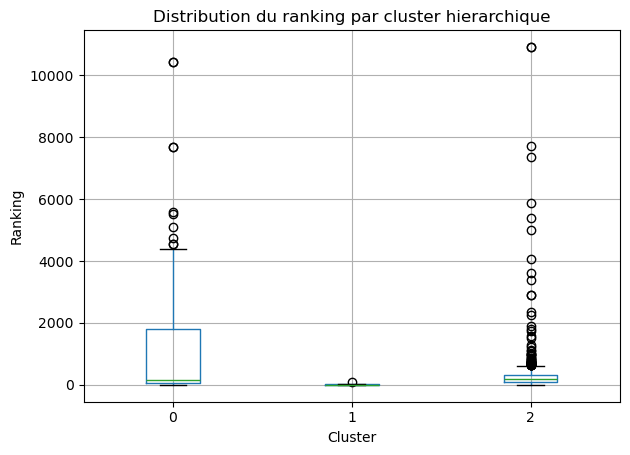

In [31]:
plt.figure(figsize=(8, 5))
data_clust_high_subset.boxplot(column='ranking', by='cluster_hier_high')
plt.title("Distribution du ranking par cluster hierarchique")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

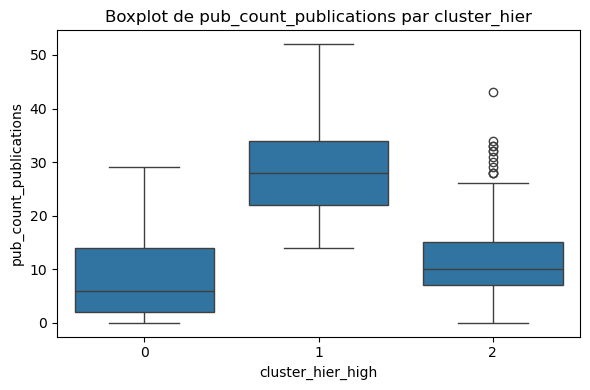

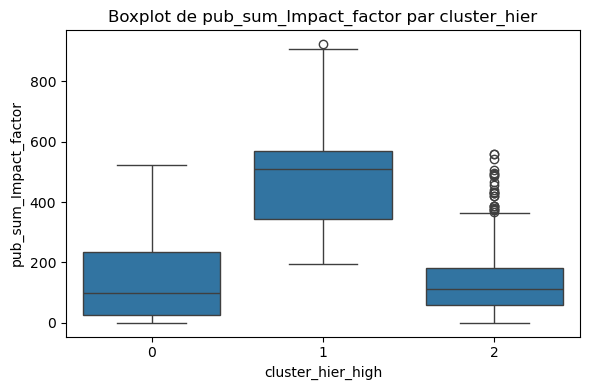

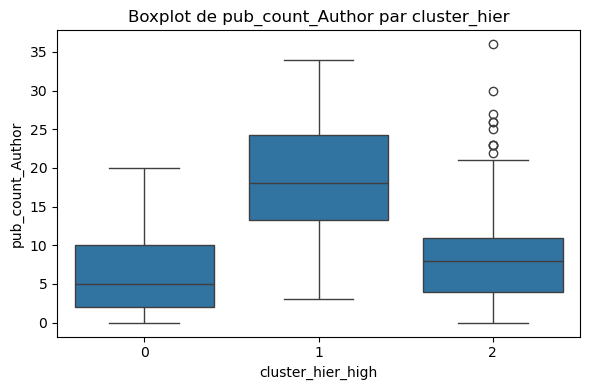

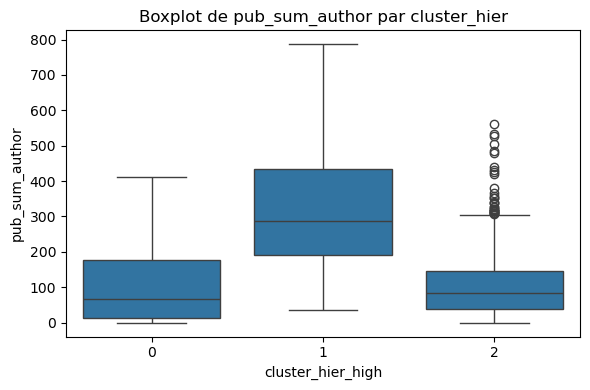

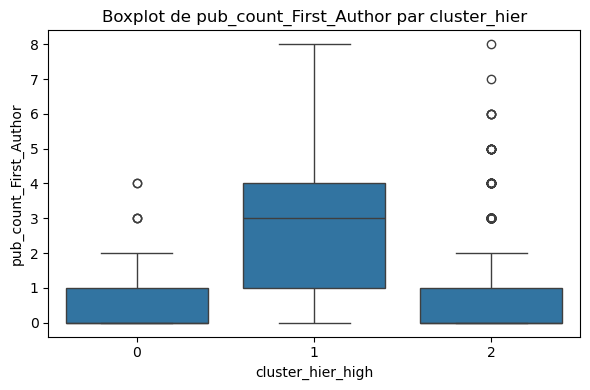

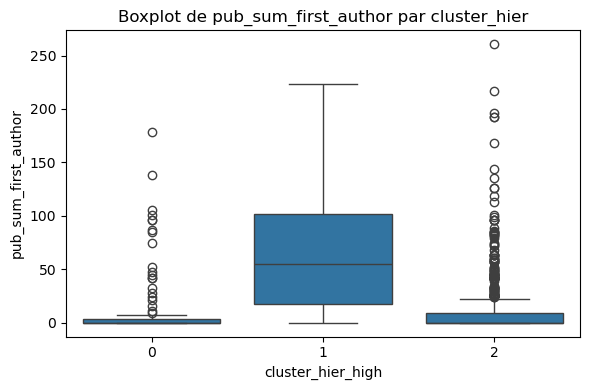

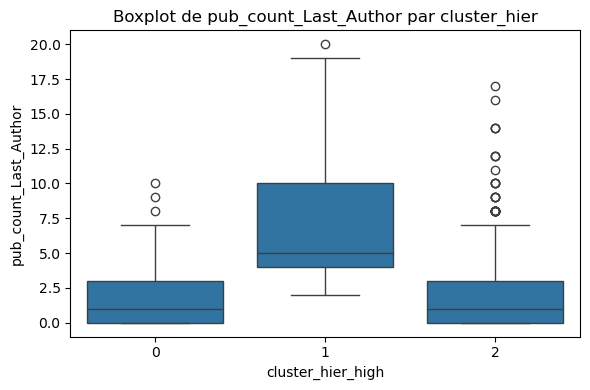

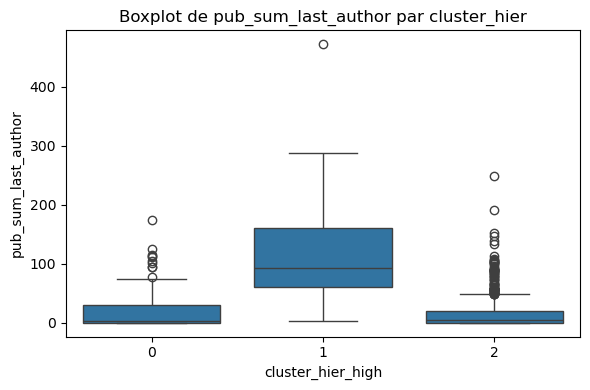

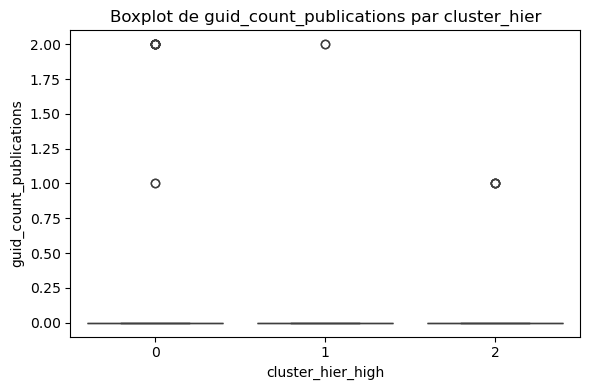

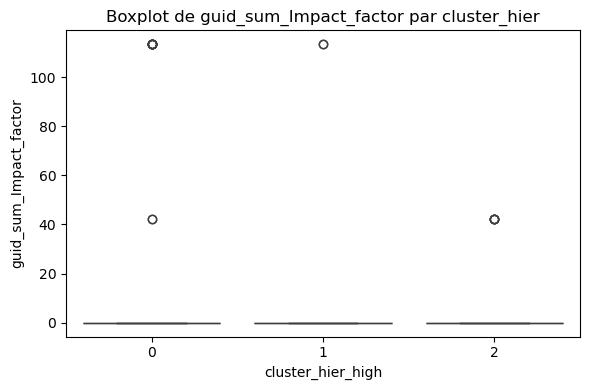

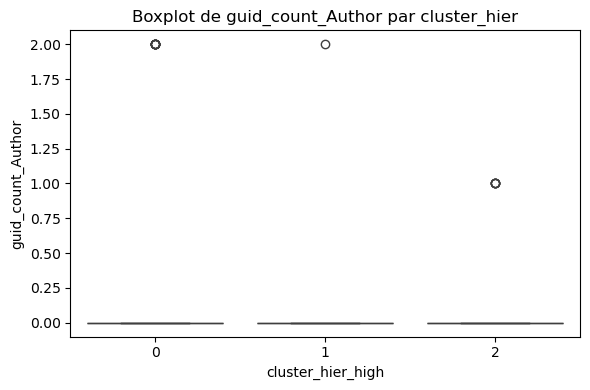

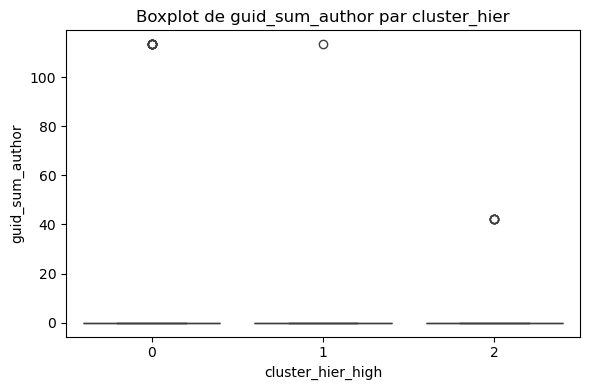

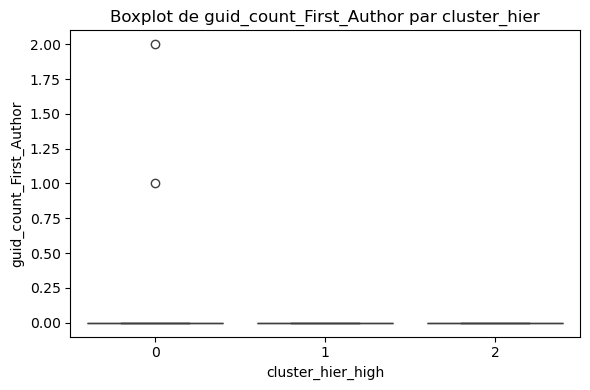

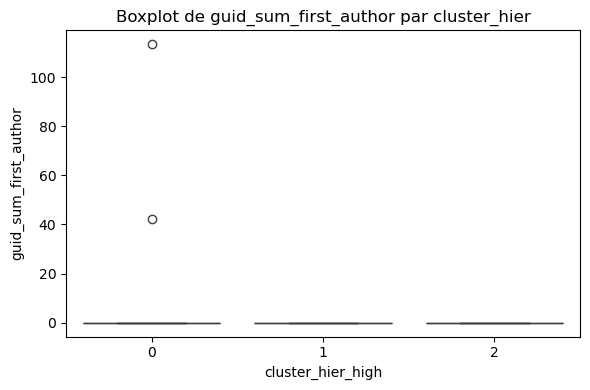

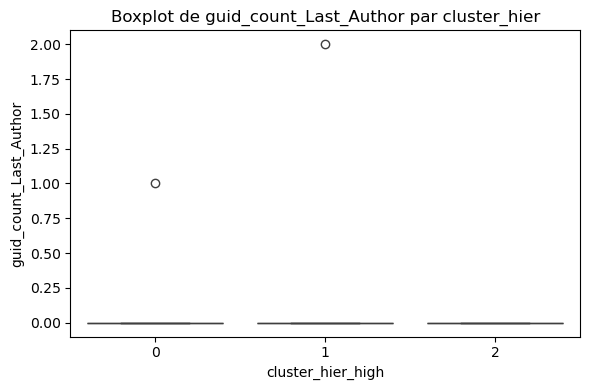

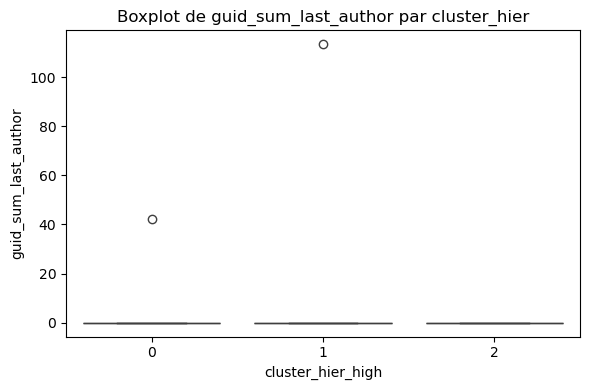

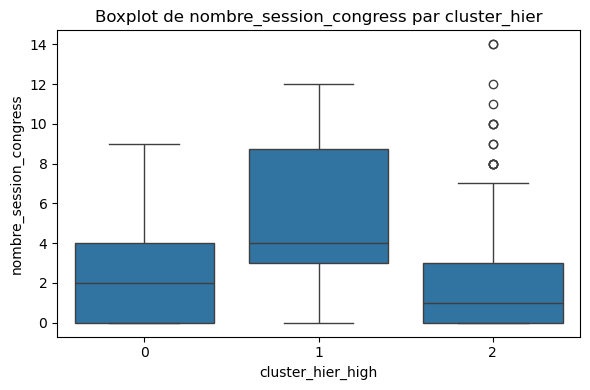

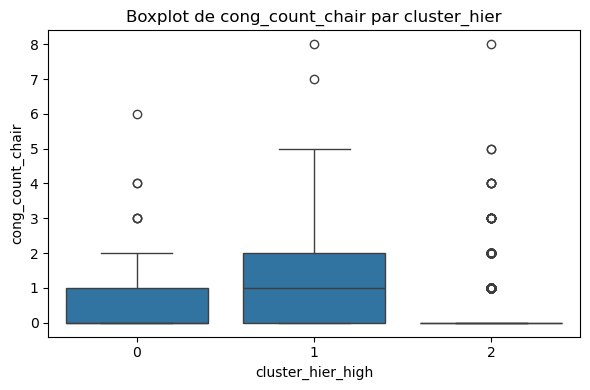

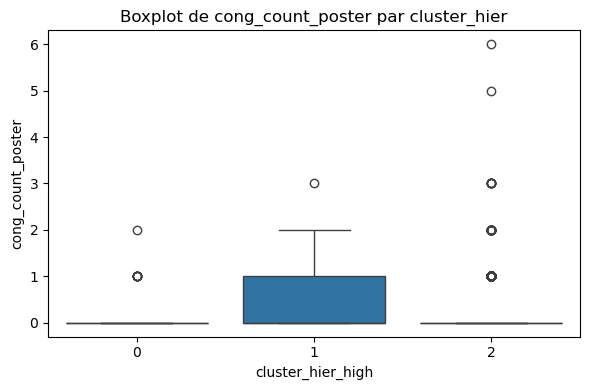

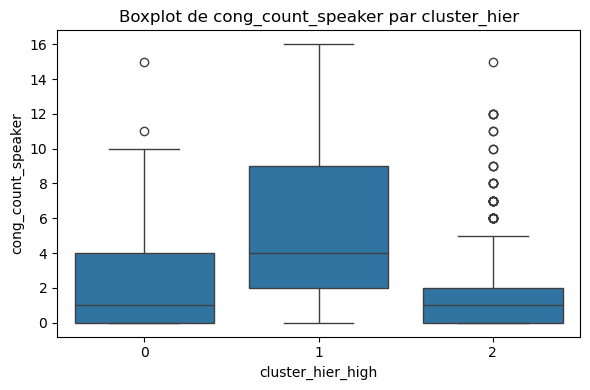

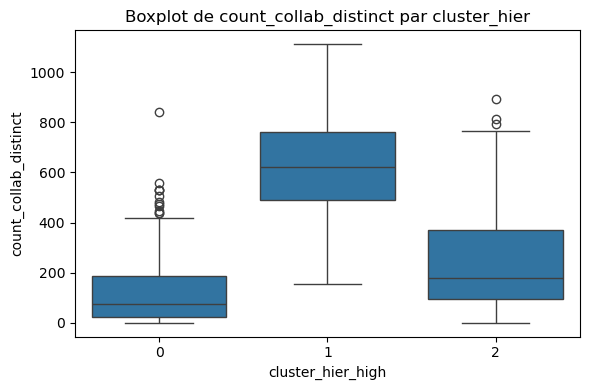

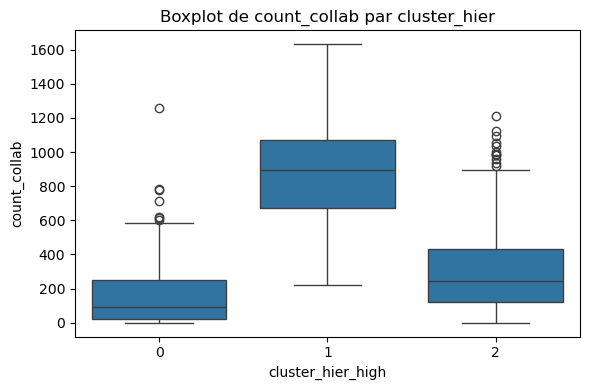

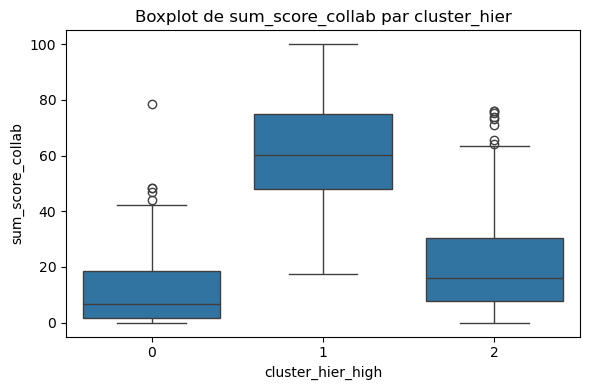

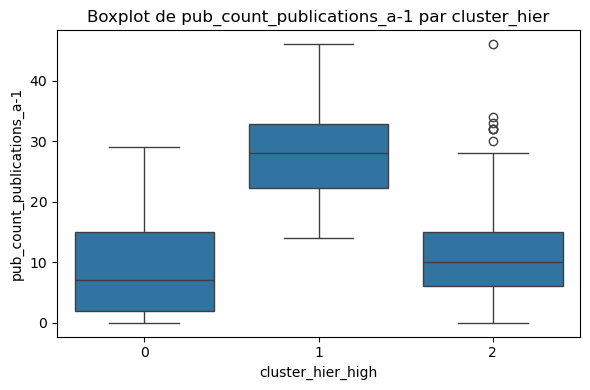

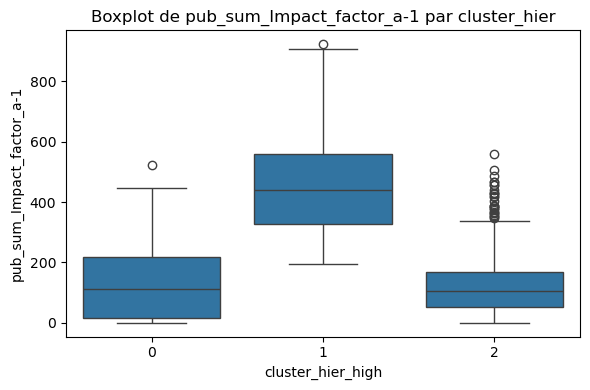

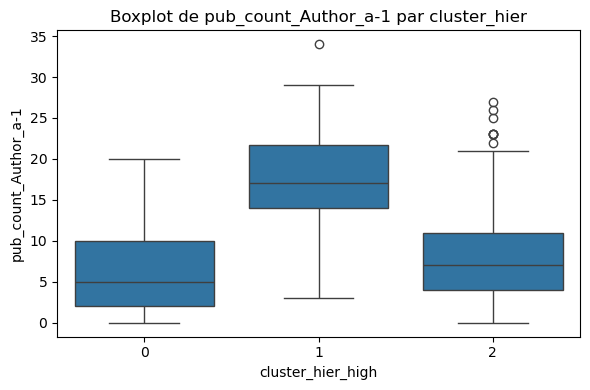

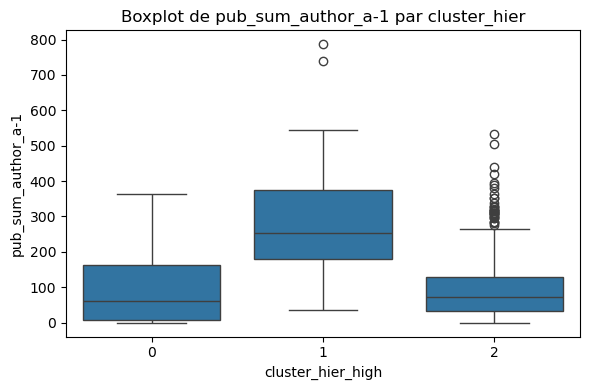

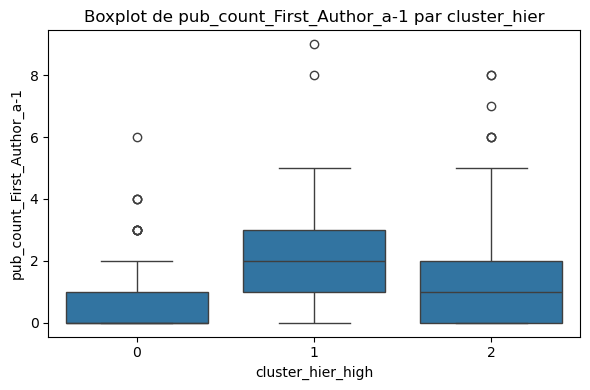

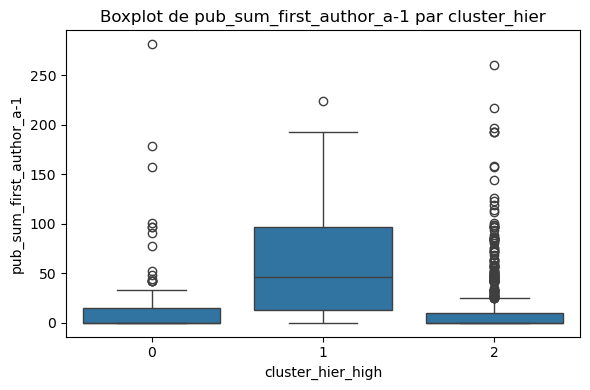

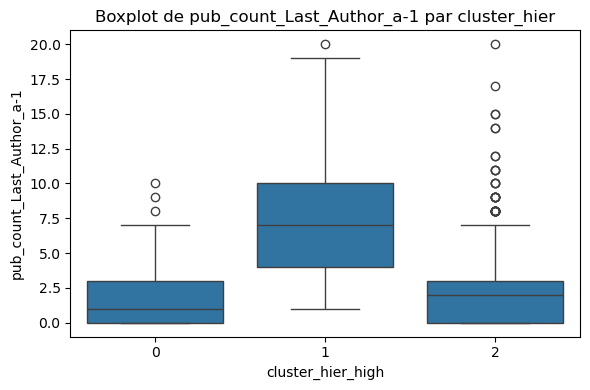

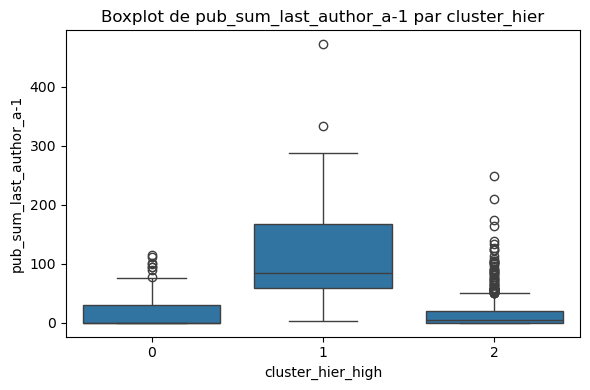

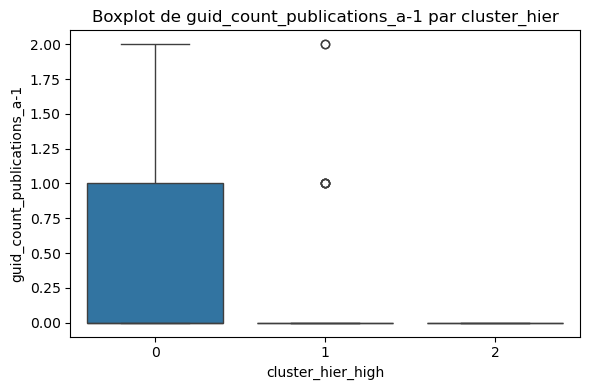

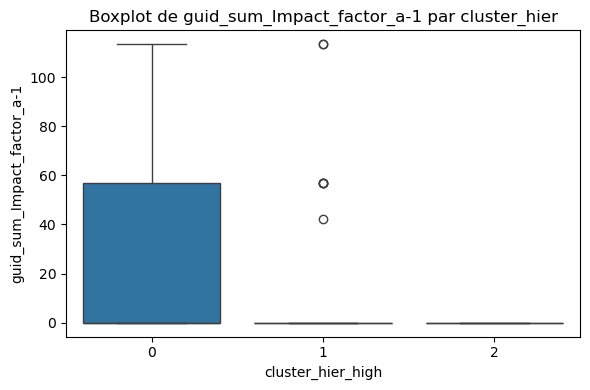

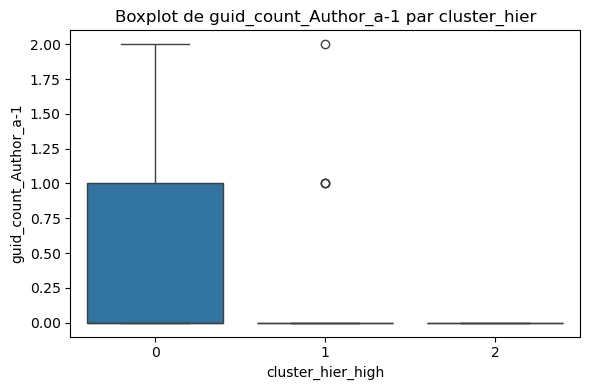

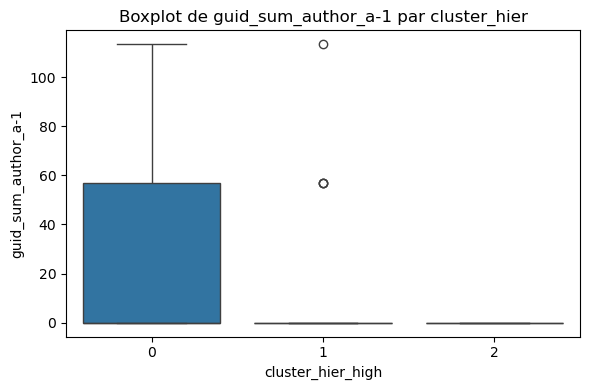

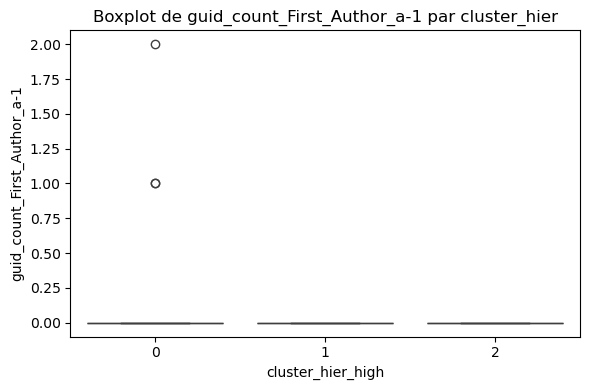

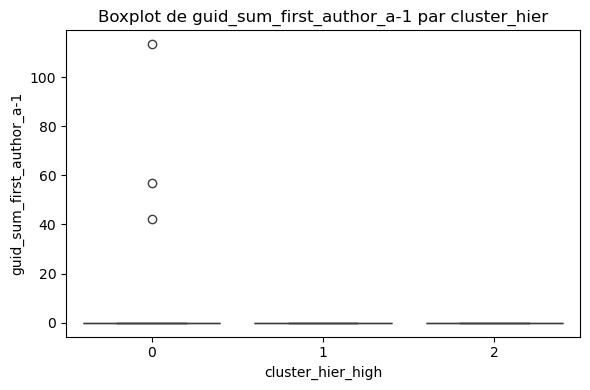

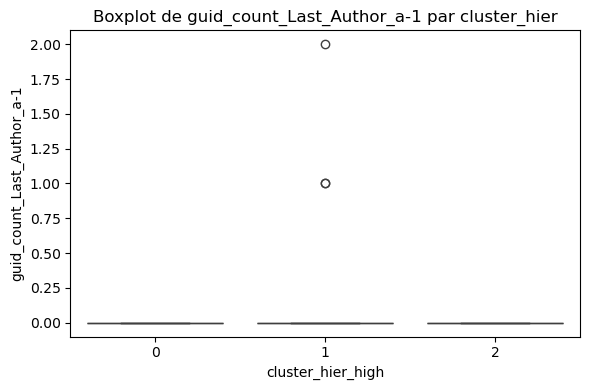

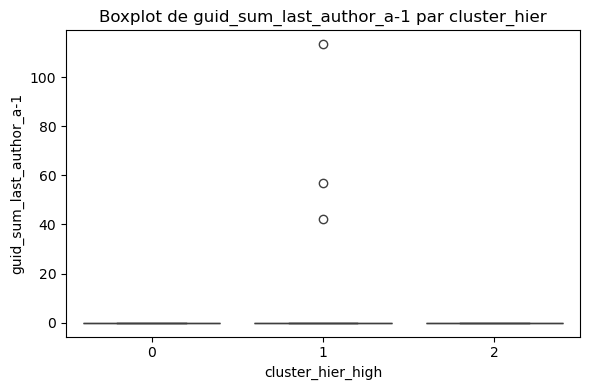

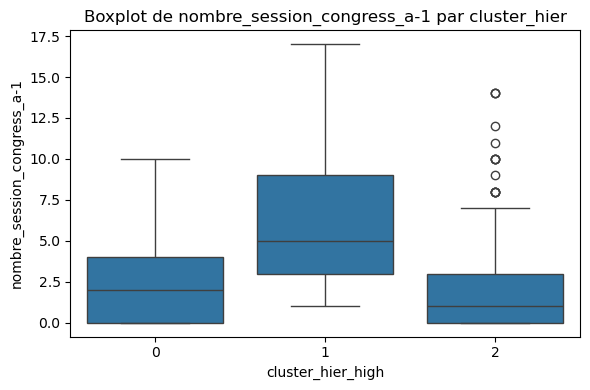

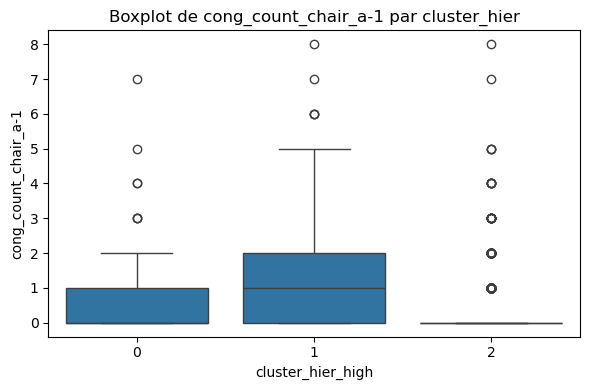

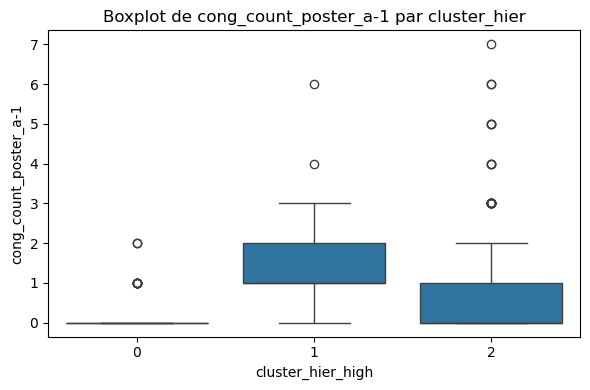

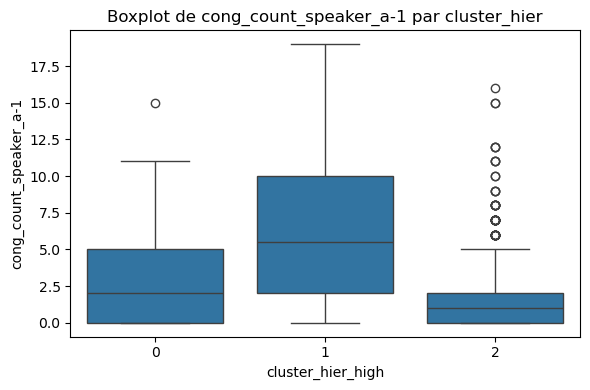

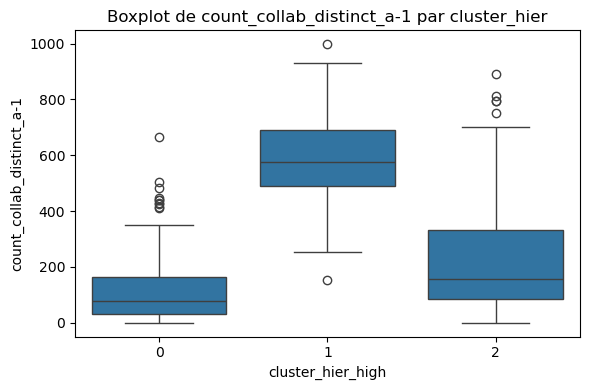

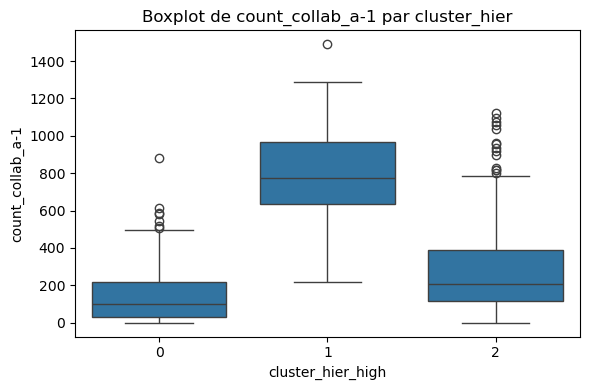

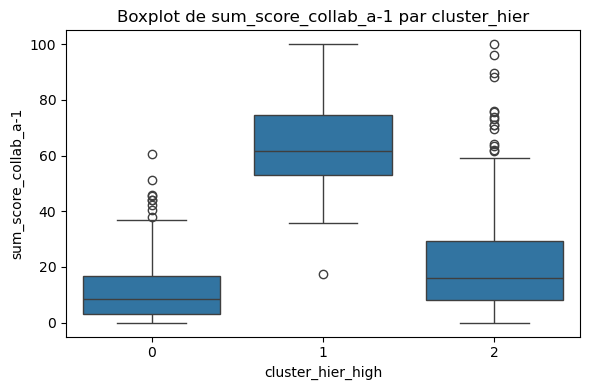

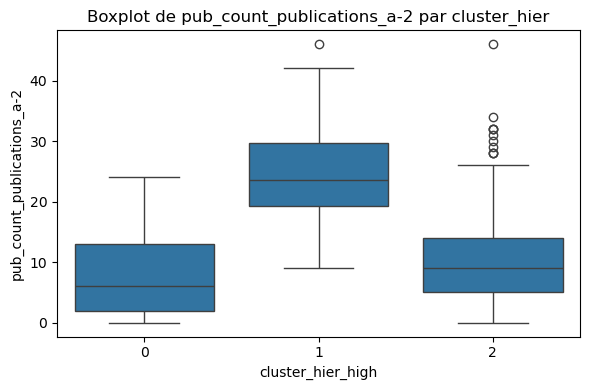

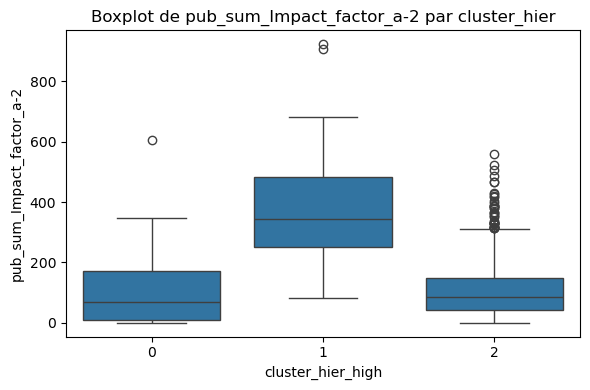

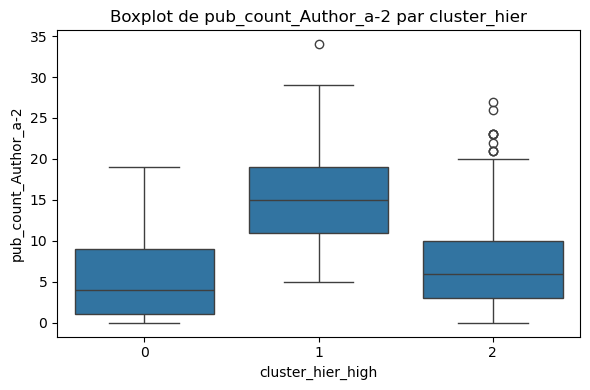

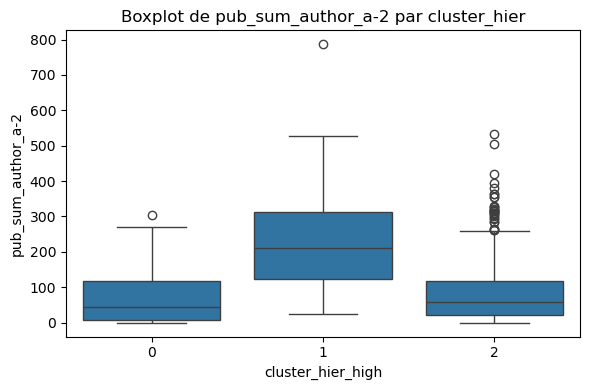

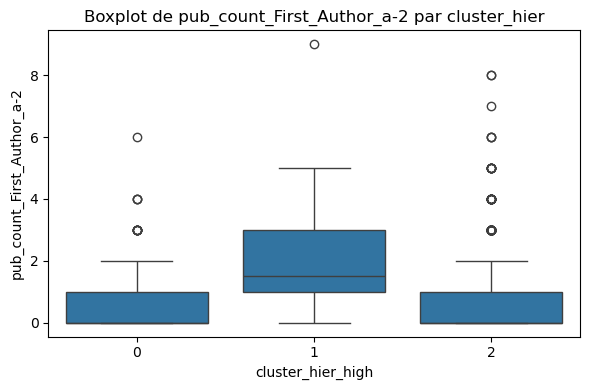

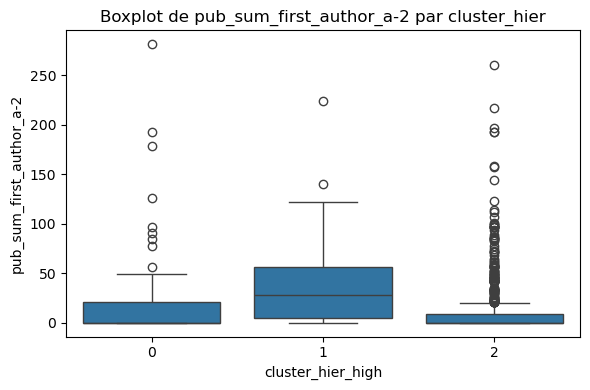

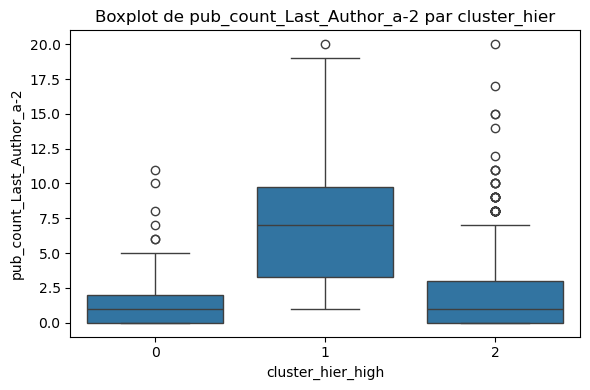

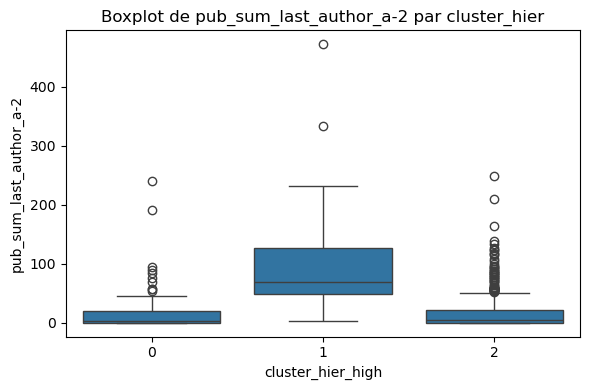

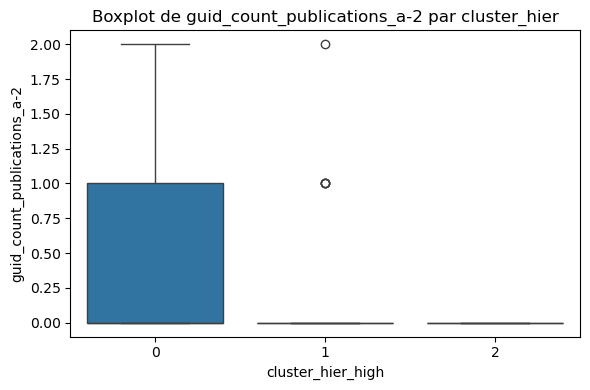

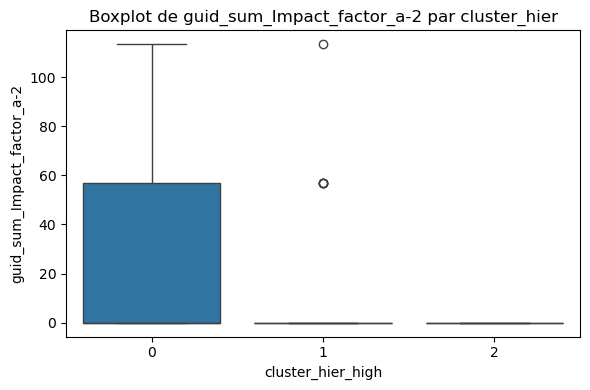

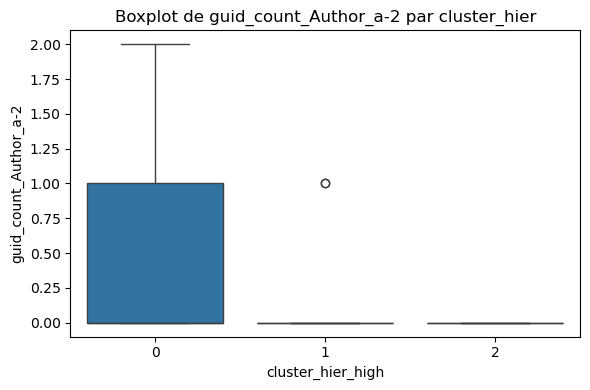

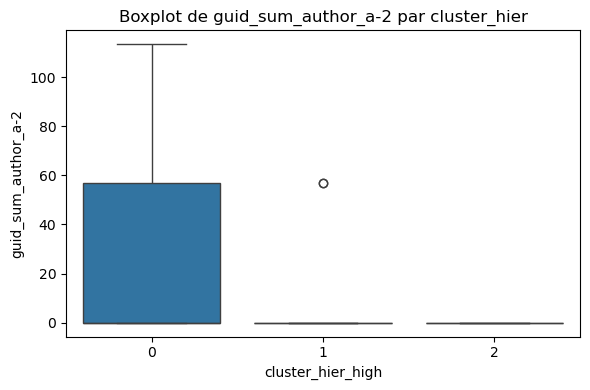

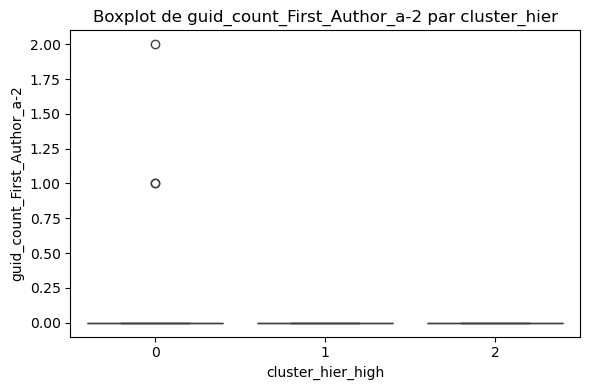

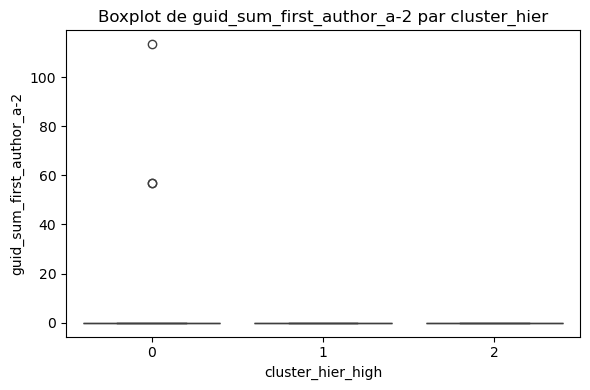

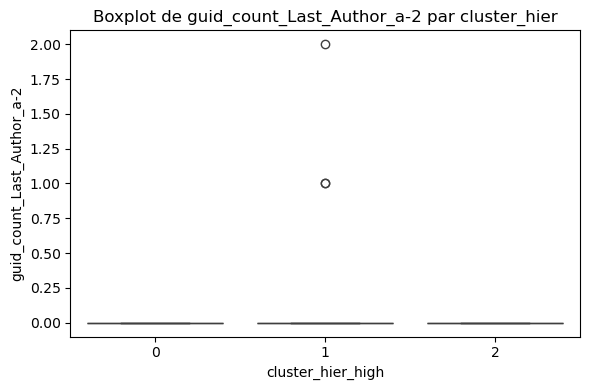

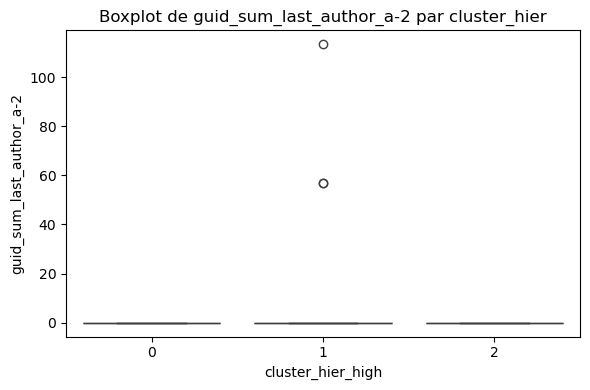

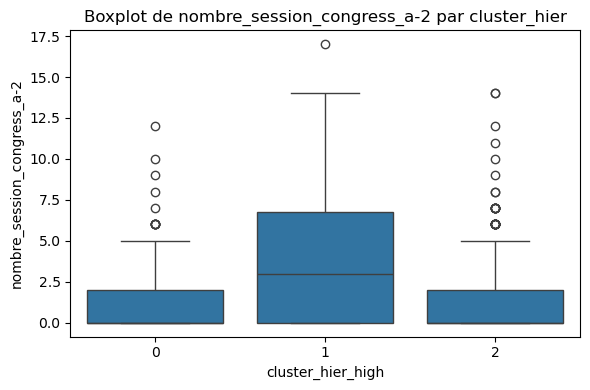

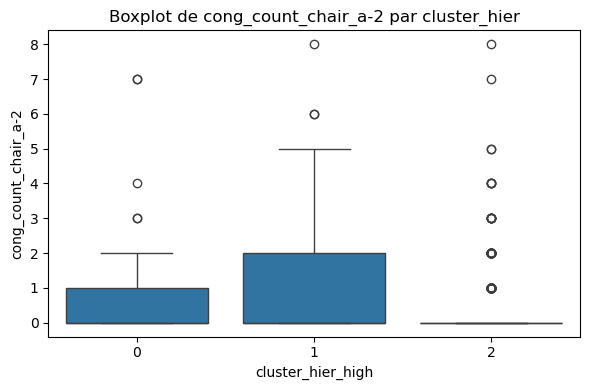

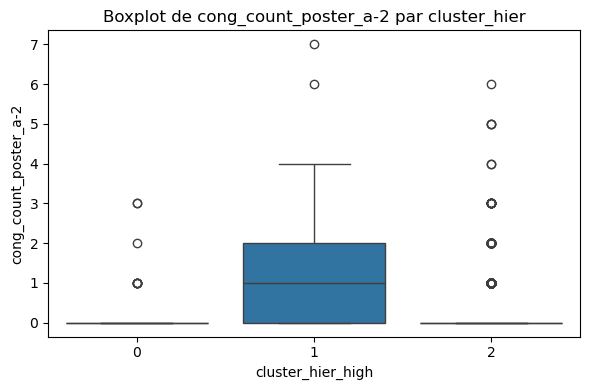

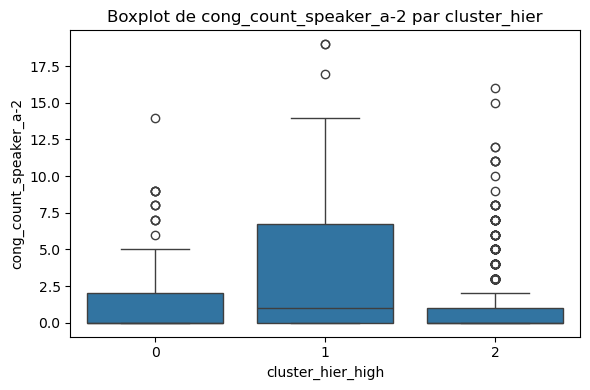

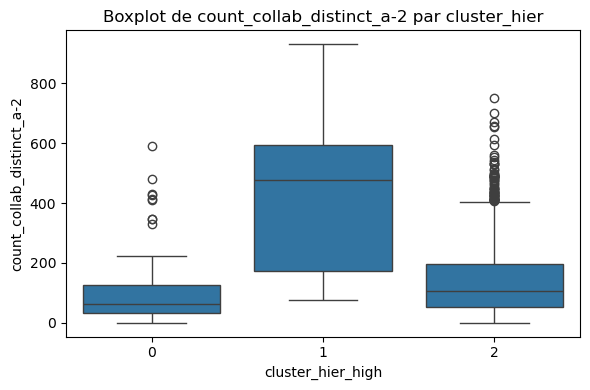

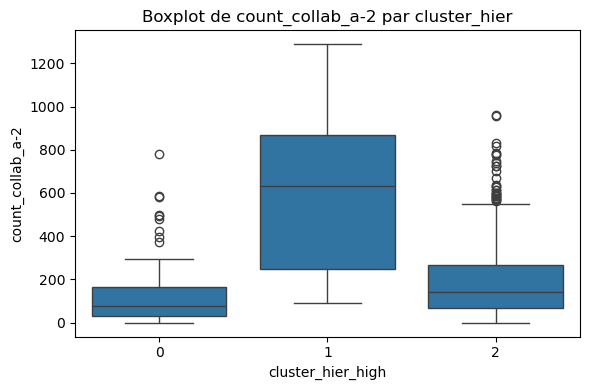

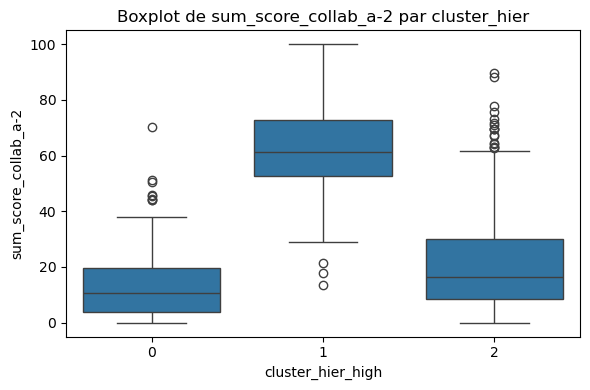

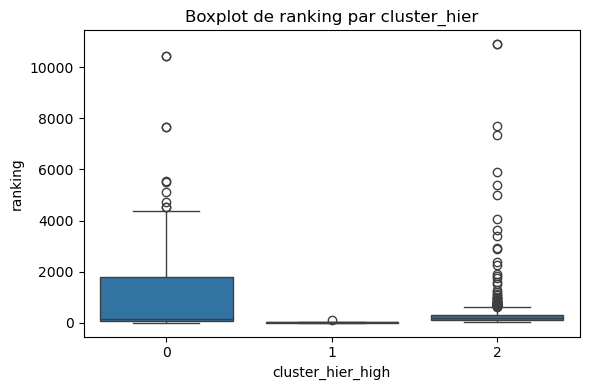

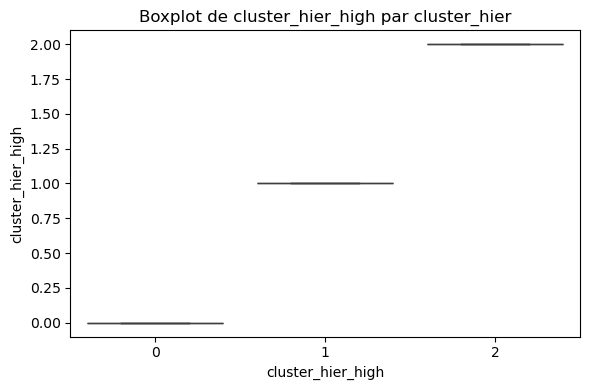

In [32]:
import seaborn as sns

# On sélectionne uniquement les variables numériques
numeric_cols = data_clust_high_subset.select_dtypes(include="number").columns

# Boucle sur chaque variable numérique pour faire un boxplot par cluster
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data_clust_high_subset, x="cluster_hier_high", y=col)
    plt.title(f"Boxplot de {col} par cluster_hier")
    plt.tight_layout()
    plt.show()

In [ ]:
# Choisis le nombre de clusters, par ex. k = 4
k = 2

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data_clust['cluster_kmeans'] = kmeans_labels

# Visualiser les premiers résultats
print(data_clust[['cluster_kmeans']].head())